In [1]:
# Retail Sales Data Cleaning and Exploratory Analysis

# Tools Used:
# Python (Pandas)
# MySQL
# SQLAlchemy


# 1..Import Required Libraries
import pandas as pd
import numpy as np

In [2]:
# 2..Load Dataset
df=pd.read_csv("retail_sales_dataset.csv")

In [3]:
# 3..inspect Dataset
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [5]:
print(df.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [6]:
print(df.shape)

(1000, 9)


In [7]:
df.duplicated().sum()


np.int64(0)

In [8]:
# 4..check missing values 
df.isnull().sum()


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [9]:
# making it easier for analysis
df.columns=df.columns.str.strip()

In [10]:
df.columns=df.columns.str.replace(" ","_")

In [11]:
df.columns=df.columns.str.lower()


In [12]:
# 5..Duplicate check
# Remove duplicates
df=df.drop_duplicates()

In [13]:
# 6..Handle Missing Values
df = df.dropna()
#or we can make use of
df['age'] = df['age'].fillna(df['age'].mean())

In [14]:
df["date"]=pd.to_datetime(df["date"])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1000 non-null   int64         
 1   date              1000 non-null   datetime64[ns]
 2   customer_id       1000 non-null   object        
 3   gender            1000 non-null   object        
 4   age               1000 non-null   int64         
 5   product_category  1000 non-null   object        
 6   quantity          1000 non-null   int64         
 7   price_per_unit    1000 non-null   int64         
 8   total_amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [16]:
# 7..Feature Engineering.
df["month"]=df["date"].dt.month
df["year"] = df["date"].dt.year

In [17]:
df.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,month,year
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,2023
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,2023
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,2023
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,2023
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,2023


In [18]:

# 8..Exploratory Data Analysis (EDA)

# Total Revenue
df["total_amount"].sum()

np.int64(456000)

In [19]:
# Sales by Product Category
df.groupby("product_category")["total_amount"].sum()

product_category
Beauty         143515
Clothing       155580
Electronics    156905
Name: total_amount, dtype: int64

In [20]:
# Sales by Product Category
df.groupby("product_category")["total_amount"].sum()

product_category
Beauty         143515
Clothing       155580
Electronics    156905
Name: total_amount, dtype: int64

In [21]:
# Monthly Sales
df.groupby("month")["total_amount"].sum()

month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: total_amount, dtype: int64

In [22]:
# 9..
df.groupby("product_category").agg({
"total_amount": ["sum", "mean", "max"],
"quantity": "sum"
})

total_amount                   quantity
                          sum        mean   max      sum
product_category                                        
Beauty                 143515  467.475570  2000      771
Clothing               155580  443.247863  2000      894
Electronics            156905  458.786550  2000      849

In [23]:
df

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,month,year
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,2023
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,2023
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,2023
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,2023
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,2023
...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5,2023
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11,2023
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10,2023
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12,2023


In [24]:

# 10..Outlier Detection using IQR Method


Q1 = df["total_amount"].quantile(0.25)
Q3 = df["total_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["total_amount"] < lower_bound) | (df["total_amount"] > upper_bound)]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 0


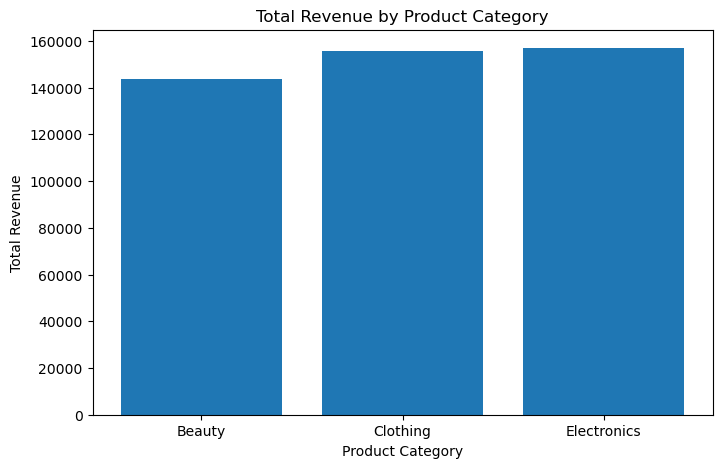

In [25]:
# data visualization using matplotlib

# Revenue by Product Category


import matplotlib.pyplot as plt

category_sales = df.groupby("product_category")["total_amount"].sum()

plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.show()

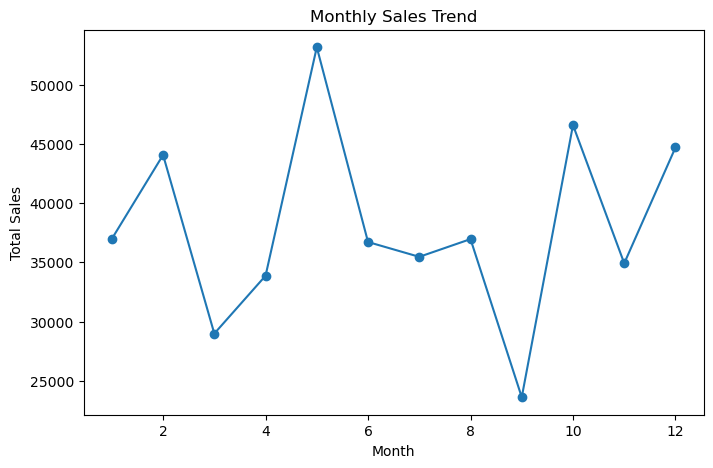

In [26]:

# Monthly Sales Trend


monthly_sales = df.groupby("month")["total_amount"].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

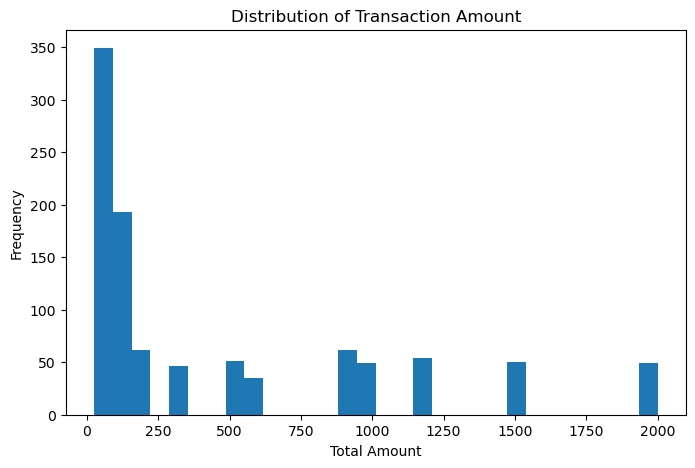

In [27]:

# Sales Distribution


plt.figure(figsize=(8,5))

plt.hist(df["total_amount"], bins=30)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

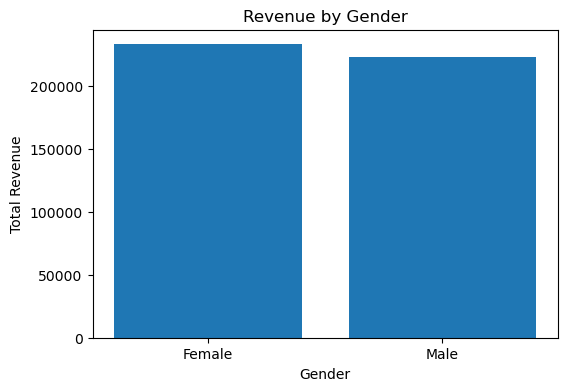

In [28]:

# Revenue by Gender


gender_sales = df.groupby("gender")["total_amount"].sum()

plt.figure(figsize=(6,4))

plt.bar(gender_sales.index, gender_sales.values)

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")

plt.show()

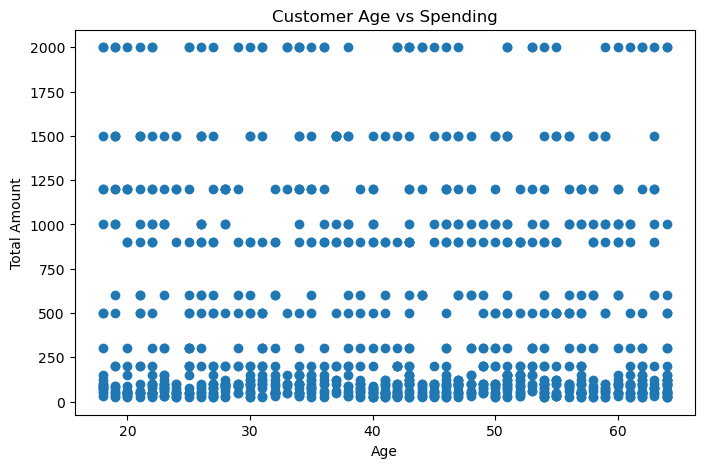

In [29]:

# Age vs Spending


plt.figure(figsize=(8,5))

plt.scatter(df["age"], df["total_amount"])

plt.title("Customer Age vs Spending")
plt.xlabel("Age")
plt.ylabel("Total Amount")

plt.show()

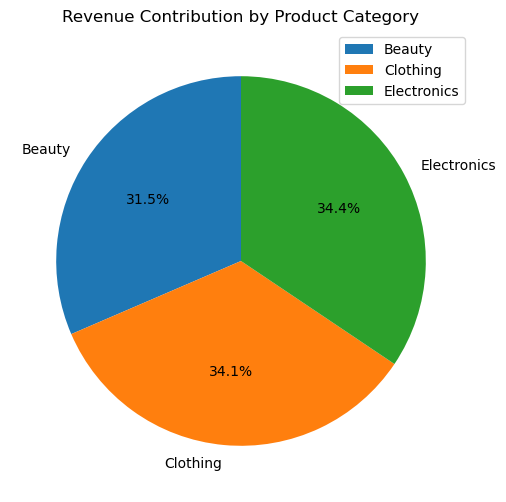

In [34]:

# Revenue Contribution by Product Category


category_sales = df.groupby("product_category")["total_amount"].sum()

plt.figure(figsize=(6,6))

plt.pie(category_sales.values,
        labels=category_sales.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Revenue Contribution by Product Category")
plt.legend()
plt.show()

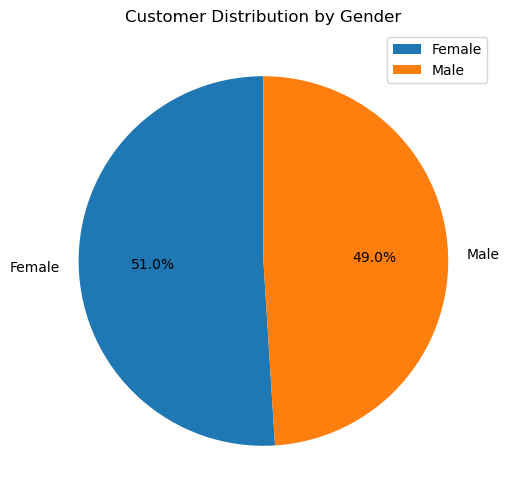

In [36]:

# Customer Distribution by Gender


gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(gender_counts.values,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Customer Distribution by Gender")
plt.legend()
plt.show()

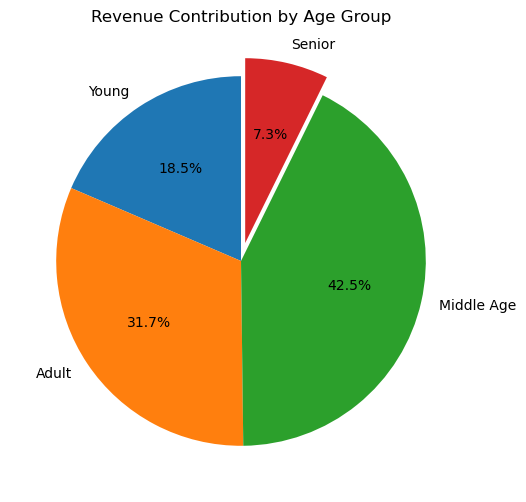

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Create age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[0,25,40,60,100],
    labels=["Young","Adult","Middle Age","Senior"]
)

# Group sales by age group
age_sales = df.groupby("age_group", observed=False)["total_amount"].sum()

# Create explode list (highlight Senior)
explode = [0, 0, 0, 0.1]

plt.figure(figsize=(6,6))

plt.pie(
    age_sales.values,
    labels=age_sales.index,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Revenue Contribution by Age Group")

plt.show()

In [33]:
# 10..Load Data into MySQL
from sqlalchemy import create_engine
username="root"
password="9972"
host="localhost"
port="3306"
database="newdatabase"

engine=create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")
table_name="retail_sales"
df.to_sql(table_name,engine,if_exists="replace",index=False)

pd.read_sql("select * from retail_sales limit 5",engine)

pd.read_sql("select age from retail_sales",engine)


,age
0,34
1,26
2,50
3,37
4,30
...,...
995,62
996,52
997,23
998,36


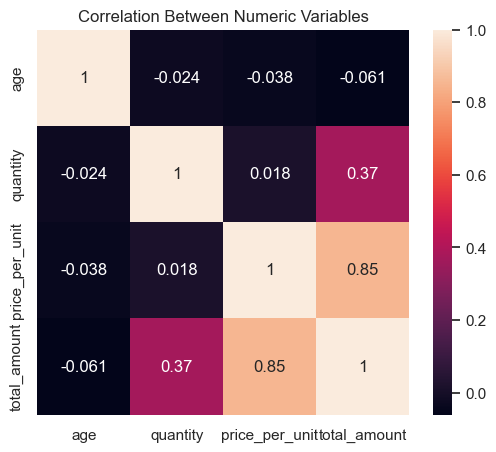

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(df[["age","quantity","price_per_unit","total_amount"]].corr(), annot=True)

plt.title("Correlation Between Numeric Variables")

plt.show()

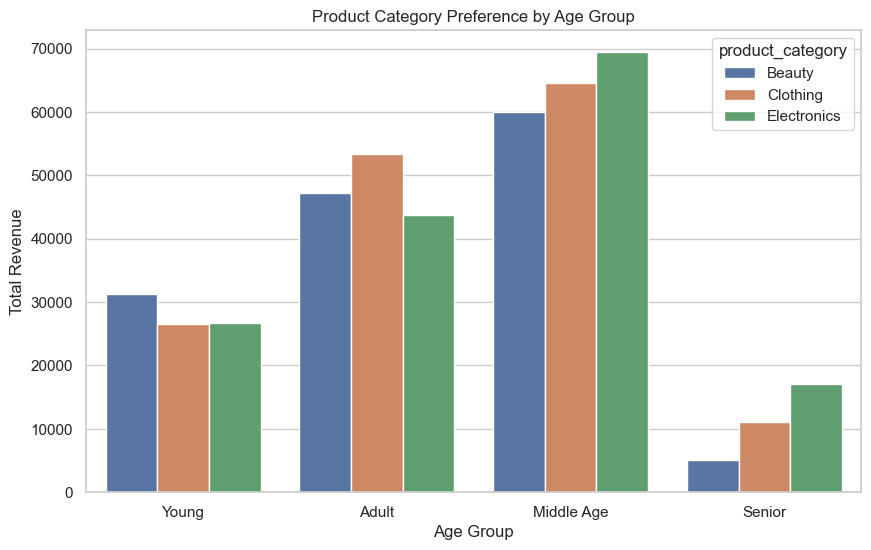

In [48]:
age_category = df.groupby(
    ["age_group","product_category"],
    observed=False
)["total_amount"].sum().reset_index()  
plt.figure(figsize=(10,6))
sns.barplot(data=age_category, x="age_group", y="total_amount", hue="product_category")

plt.title("Product Category Preference by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")

plt.show()

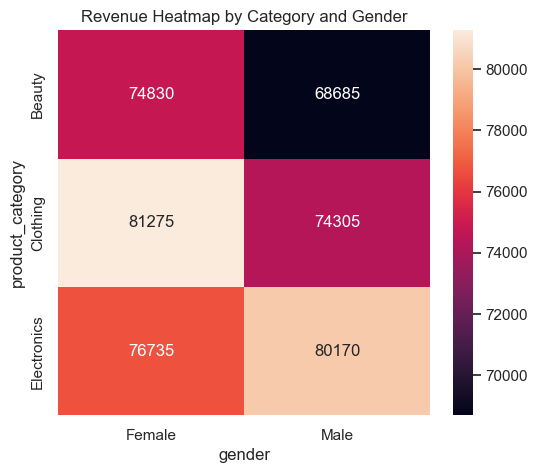

In [47]:
pivot_table = df.pivot_table(
    values="total_amount",
    index="product_category",
    columns="gender",
    aggfunc="sum"
)

plt.figure(figsize=(6,5))
sns.heatmap(pivot_table, annot=True, fmt=".0f")

plt.title("Revenue Heatmap by Category and Gender")

plt.show()